# Clustering, Anomaly Detection and Generative Modeling using Gaussian Mixture Model

_**Develop a program to train a Gaussian mixture model on an appropriate dataset, perform clustering, anomaly detection and also use it as a generative model.**_

In [ ]:
# Import required packages

import numpy as np
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt


## Generating Dataset

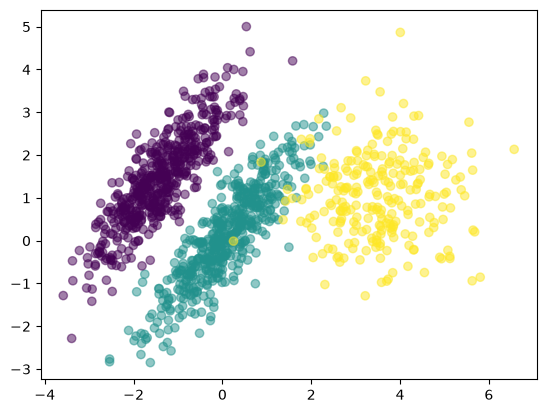

In [75]:
# Generates the synthetic dataset with three ellipsoids with size distribution of 2:2:1

X1, y1 = make_blobs(
    n_samples=1000,             # Two of the clusters to be generated with 500 instances each
    centers=((4, -4), (0, 0)),  # Two centers to generate
    random_state=42)

# Multiplies each sample by the 2×2 matrix to give the initially blob-shaped clusters a elliptical shape
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))  

X2, y2 = make_blobs(
    n_samples=250,          # Third cluster to contain 250 instances
    centers=1, 
    random_state=42)
X2 = X2 + [6, -8]           # Shifts the cluster right by 6 and down by 8
y2 = np.full(len(X2), 2)    # Changes the labels of the thrid cluster elements to `2`

# Concatentates two clusters along the second-axis
X = np.r_[X1, X2]           # For cluster samples
y = np.r_[y1, y2]           # For cluster labels

# Visualizes the clusters
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.5)
plt.show()

## Finding Optimal Number of _k_ in Gaussian Distribution
Rather than manually searching for the optimal number of clusters using metrics such as _Akaike Information Criterion_ (AIC) or _Bayesian Information Criterion_ (BIC), `BayesianGaussianMixture` class is capable of giving weights equal (or close) to zero to unnecessary clusters provided the set number of components believed to be greater than the optimal number of clusters.

In [76]:
bgmm = BayesianGaussianMixture(
    n_components=10,    # The number of cluster is believed to be greater than the optimal number of clusters
    n_init=30,          # The number of expectation-maximization (EM) iterations to perform
    random_state=42)

bgmm.fit(X)             # Fits the model on the dataset

bgmm.weights_.round(2)  # Checks if the weight of any cluster is equal or close to zero meaning those clusters to be unneccessary

array([0.4 , 0.21, 0.4 , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

Except for the weights for the first three cluster the remaining weights are zero indicating only 3 components are needed.

## Clustering

In [77]:
gmm = GaussianMixture(
    n_components=3,         # Based on cluster weights found by Bayesian Gaussian mixture model in the previous step
    covariance_type="full", # Each component to have its own general covariance matrix
    n_init=10,
    random_state=42)

gmm.fit(X)                  # Fits the model on the dataset

,"n_components n_components: int, default=1The number of mixture components.",3
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None


In [78]:
# Checks if the Estimated mixing weights for each of the distributions matches with true cluster weights
# (Learns the cluster size distribution)
gmm.weights_

array([0.40005972, 0.20961444, 0.39032584])

In [79]:
# Checks if the estimated mean for each of the distributions matches with the true mean
# (Learns the cluster positions)
gmm.means_

array([[-1.40764129,  1.42712848],
       [ 3.39947665,  1.05931088],
       [ 0.05145113,  0.07534576]])

In [80]:
# Estimated general covarience matrix for each cluster
# (Learns the spread and orientation of the clusters -
#   diagonal entries represents the spread of the data along each individual feature axis,
#   off-diagonal entries represents the statistical relationship between different features
# )
gmm.covariances_

array([[[ 0.63478217,  0.72970097],
        [ 0.72970097,  1.16094925]],

       [[ 1.14740131, -0.03271106],
        [-0.03271106,  0.95498333]],

       [[ 0.68825143,  0.79617956],
        [ 0.79617956,  1.21242183]]])

In [81]:
# Checks if the algorithm converged and if so, at which iteration
gmm.converged_, gmm.n_iter_

(True, 4)

In [82]:
# Predicts which cluster each instance belongs to (hard clustering) or estimate the probabilities (soft clustering) 
# that each instance belongs to a cluster

print(gmm.predict(X))                   # Hard clustering

[2 2 0 ... 1 1 1]


In [83]:
print(gmm.predict_proba(X).round(2))    # Soft clustering

[[0.   0.02 0.98]
 [0.   0.02 0.98]
 [1.   0.   0.  ]
 ...
 [0.   1.   0.  ]
 [0.   1.   0.  ]
 [0.   1.   0.  ]]


## Gaussian Mixture Model as a Generative Model

In [84]:
X_new, y_new = gmm.sample(10)   # Generates random samples from the fitted model

print(y_new)    # Checks the labels of the sampled instances in clusters

[0 0 0 1 1 1 1 1 2 2]


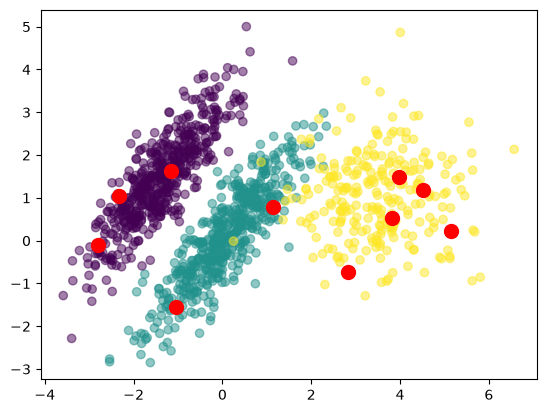

In [85]:
# Visualizes instances in the clusters
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.5)
plt.scatter(X_new[:,0], X_new[:,1], s=100, c="red", alpha=1.0)
plt.show()

## Anomaly Detection

In [86]:
# Computes the log of the probability density function (PDF) of each instance;
# Greater the score, the higher the density
densities = gmm.score_samples(X)    
print(densities.round(2))

[-2.61 -3.57 -3.33 ... -3.51 -4.4  -3.81]


In [87]:
# Computes qth-percentile to be treated as density threshold below which
# instances will be considered anomalies
density_threshold = np.percentile(densities, q=2) 
print(f"Density threshold: {density_threshold:.2f}")

anomalies = X[densities < density_threshold]    # Seperates instances with density below than the threshold
print(f"Number of anomalsy instances: {len(anomalies)}")

Density threshold: -5.94
Number of anomalsy instances: 25


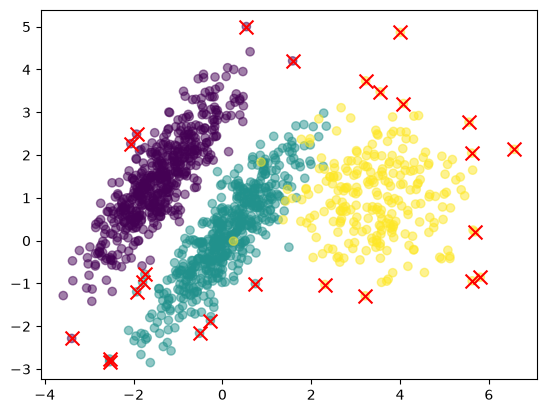

In [88]:
# Visualizes the clusters with anomalies red cross marked
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.5)
plt.scatter(anomalies[:,0], anomalies[:,1], s=100, c="red", marker="x", alpha=1.0)
plt.show()

**Observations**:

1. Synthetic dataset with three ellipsoids with size of specified distribution was generated.
2. Bayesian Gaussian Mixture was used to compute weights for the clusters over EM iterations to estimate the required number cluster
3. Gaussian mixture models learned the cluster size distribution (over weights), cluster positions (over means), and spread and orientation (over covariances)
4. Gaussian mixture model learned to generate new samples from multiple distributions.
5. Gaussian mixture model was used to perform anomaly detection upon a threshold computed over log of probability density function (PDF) for each cluster instances.